In [ ]:
!pip install scapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 29.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import os

# 1. List the files in your current folder to make sure we see them
print("Files in current directory:", os.listdir())

# 2. Try to find the Wednesday file (handling potential name variations)
target_file = 'Wednesday-workingHours.pcap_ISCX.csv'

def clean_dataset(df):
    # Remove hidden spaces in column names
    df.columns = df.columns.str.strip()

    # Drop non-behavioral columns
    drop_cols = ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Timestamp']
    df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

    # Handle math errors (Infinity) and missing values (NaN)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    return df

# 3. Execution
try:
    print(f"\nReading {target_file}...")
    # This might take a minute because the file is large
    df = pd.read_csv(target_file)

    print("Cleaning data...")
    df_cleaned = clean_dataset(df)

    print(f"✅ Success! Data Cleaned.")
    print(f"Total Rows: {len(df_cleaned)}")
    print(f"Attack Types found: {df_cleaned['Label'].unique()}")

    # Save a smaller, cleaned version for the next step
    df_cleaned.to_csv('cleaned_wednesday.csv', index=False)
    print("Cleaned file saved as 'cleaned_wednesday.csv'")

except FileNotFoundError:
    print(f"❌ Error: I couldn't find '{target_file}' in this folder.")
    print("Please make sure the script and the CSV are in the same place.")

Files in current directory: ['.config', 'Wednesday-workingHours.pcap_ISCX.csv', 'sample_data']

Reading Wednesday-workingHours.pcap_ISCX.csv...
Cleaning data...
✅ Success! Data Cleaned.
Total Rows: 691406
Attack Types found: ['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye'
 'Heartbleed']
Cleaned file saved as 'cleaned_wednesday.csv'


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Load the cleaned data we just made
df = pd.read_csv('cleaned_wednesday.csv')

# 2. Encode the Labels (e.g., 'BENIGN' -> 0, 'DoS Hulk' -> 1)
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])
print("Label Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# 3. Separate Features (X) and Target (y)
X = df.drop('Label', axis=1)
y = df['Label']

# 4. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Label Mapping: {'BENIGN': np.int64(0), 'DoS GoldenEye': np.int64(1), 'DoS Hulk': np.int64(2), 'DoS Slowhttptest': np.int64(3), 'DoS slowloris': np.int64(4), 'Heartbleed': np.int64(5)}

Training set size: 553124
Testing set size: 138282


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize the Model
# We use n_jobs=-1 to use all your CPU cores for faster training
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

print("Training the Random Forest (this may take a 1-3 minutes)...")
rf_model.fit(X_train, y_train)

# 2. Make Predictions
y_pred = rf_model.predict(X_test)

# 3. Evaluate the results
print("\n✅ Training Complete!")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Training the Random Forest (this may take a 1-3 minutes)...

✅ Training Complete!
Overall Accuracy: 0.9994

Detailed Classification Report:
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00     87937
   DoS GoldenEye       1.00      1.00      1.00      2059
        DoS Hulk       1.00      1.00      1.00     46025
DoS Slowhttptest       0.99      0.99      0.99      1100
   DoS slowloris       0.99      0.99      0.99      1159
      Heartbleed       1.00      1.00      1.00         2

        accuracy                           1.00    138282
       macro avg       1.00      1.00      1.00    138282
    weighted avg       1.00      1.00      1.00    138282



/tmp/ipykernel_7563/309264226.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


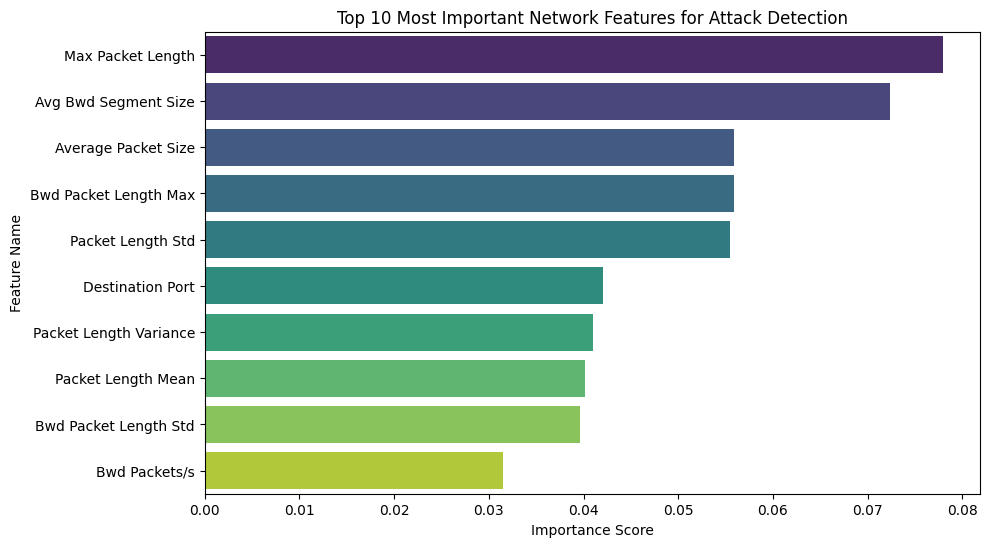


Top 5 Features:
['Max Packet Length', 'Avg Bwd Segment Size', 'Average Packet Size', 'Bwd Packet Length Max', 'Packet Length Std']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get feature importance from the model
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# 2. Sort and take the top 10
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Most Important Network Features for Attack Detection')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

print("\nTop 5 Features:")
print(feature_importance_df['Feature'].head(5).to_list())

In [ ]:
from scapy.all import sniff, IP, TCP
import numpy as np

def analyze_packet(packet):
    if packet.haslayer(IP) and packet.haslayer(TCP):
        # Extracting a few features to demonstrate real-time logic

        src_ip = packet[IP].src
        dst_port = packet[TCP].dport
        packet_len = len(packet)

        # Simple Logic: How it would look if we fed it to the model
        # raw_features = np.array([packet_len, ...]) # mapped to your model's input
        # prediction = rf_model.predict(raw_features)

        print(f"🔍 [Live Scan] {src_ip} -> Port {dst_port} | Length: {packet_len} bytes")

        # Example of a manual threshold based on your feature importance
        if len(packet) > 1500: # Example threshold
            alert_msg = f"⚠️ ALERT: Potential anomaly from {packet[IP].src} | Length: {len(packet)}"
            print(alert_msg)

            # Save to a log file
            with open("security_alerts.log", "a") as f:
                f.write(alert_msg + "\n")

print("🚀 Starting Real-Time Sniffer (Press Ctrl+C to stop)...")
# sniff(count=10, prn=analyze_packet) # This sniffs 10 packets

🚀 Starting Real-Time Sniffer (Press Ctrl+C to stop)...


In [ ]:
import joblib

# Save the trained model
joblib.dump(rf_model, 'cyber_attack_rf_model.pkl')

# Save the scaler (important: live data must be scaled the same way!)
joblib.dump(scaler, 'network_scaler.pkl')

# Save the label encoder
joblib.dump(le, 'label_encoder.pkl')

print("✅ Model, Scaler, and Encoder saved successfully!")

✅ Model, Scaler, and Encoder saved successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')